# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iankitthakur/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
!pip -q install duckdb
import os, json, duckdb, pandas as pd, numpy as np
from google.colab import userdata

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")
rel = "hf://datasets/FlyRank/internship-warehouse"
con.execute(f"""
CREATE OR REPLACE VIEW march AS
SELECT * FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/*.parquet')
""")

frame = con.sql("""
SELECT
  client_hash_id, content_hash_id,
  SUM(gsc_impressions)  FILTER (WHERE report_date <= DATE '2026-03-15') AS early_impressions,
  SUM(gsc_clicks)       FILTER (WHERE report_date <= DATE '2026-03-15') AS early_clicks,
  SUM(gsc_clicks) FILTER (WHERE report_date <= DATE '2026-03-15') * 1.0
    / NULLIF(SUM(gsc_impressions) FILTER (WHERE report_date <= DATE '2026-03-15'), 0) AS early_ctr,
  AVG(gsc_avg_position) FILTER (WHERE report_date <= DATE '2026-03-15') AS early_avg_position,
  COUNT(*) FILTER (WHERE report_date <= DATE '2026-03-15' AND gsc_impressions > 0) AS early_active_days,
  SUM(gsc_impressions)  FILTER (WHERE report_date >  DATE '2026-03-15') AS late_impressions
FROM march
WHERE gsc_data_available IS TRUE
  AND hash(content_hash_id) % 50 = 0
GROUP BY 1, 2
""").df()

df = frame[frame["early_impressions"] >= 20].copy()
df["late_impressions"] = df["late_impressions"].fillna(0)
df["label_declining"] = ((df["late_impressions"] / 16) < 0.8 * (df["early_impressions"] / 15)).astype(int)
df = df.sort_values(["client_hash_id", "content_hash_id"]).reset_index(drop=True)   # repeatable row order
y = df["label_declining"]
print(df.shape, "declining rate:", round(y.mean(), 3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(2191, 9) declining rate: 0.329


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


How the ranking works: each page gets a score equal to the clicks it earned below what pages at the same average position earned (peer CTR from pages in my sample, early window 1–15 March only). Pages are ranked by that score, and each gets one reason code and one action from the table below. I use this rule, not a model, because under a grouped-by-client split no model clearly beat it (Precision@50 about 0.40 against a base rate of 0.329), and an editor can read a rule. The reason code says which pattern put the page in the queue; it is not a cause.

In [4]:
d = df.dropna(subset=["early_avg_position", "early_ctr"]).copy()
d["pos_bucket"] = pd.cut(d["early_avg_position"], [0, 3, 10, 20, 1000], labels=["1-3", "4-10", "11-20", "21+"]).astype(str)
sums = d.groupby("pos_bucket")[["early_clicks", "early_impressions"]].sum()
d["peer_ctr"] = d["pos_bucket"].map(sums["early_clicks"] / sums["early_impressions"])
d["score"] = (d["peer_ctr"] * d["early_impressions"] - d["early_clicks"]).clip(lower=0).round(1)   # clicks below peers at the same position

d["archetype"] = np.select(
    [d["early_impressions"] < 100, d["score"] == 0, d["early_avg_position"] <= 10, d["early_avg_position"] <= 20],
    ["Low demand", "At or above peers", "Top-10 under-clicker", "Page-2 under-clicker"],
    default="Deep under-clicker (21+)")

playbook = pd.DataFrame([
    ["Top-10 under-clicker",       "CTR_BELOW_PEERS_TOP10",  "Rewrite title and meta description",           "Yes"],
    ["Page-2 under-clicker",       "CTR_BELOW_PEERS_PAGE2",  "Improve content depth and intent match",       "Yes"],
    ["Deep under-clicker (21+)",   "CTR_BELOW_PEERS_DEEP",   "Review search intent; consider merge or prune only after a human check", "Yes"],
    ["Low demand",                 "LOW_DEMAND",             "Monitor",                                      "No"],
    ["At or above peers",          "AT_OR_ABOVE_PEER_CTR",   "Protect: no change",                           "No"],
], columns=["archetype", "reason_code", "action", "human_review_required"])
d = d.merge(playbook, on="archetype", how="left")

queue = d[d["archetype"].isin(["Top-10 under-clicker", "Page-2 under-clicker", "Deep under-clicker (21+)"])] \
         .sort_values("score", ascending=False).reset_index(drop=True)
queue.insert(0, "rank", queue.index + 1)

print("pages scored:", len(d), "| pages in the review queue:", len(queue))
print("Precision@50 of the queue (evaluation only):", round(queue.head(50)["label_declining"].mean(), 3),
      "| base rate:", round(y.mean(), 3))
queue[["rank", "score", "reason_code", "action", "early_impressions", "early_clicks", "early_avg_position"]].head(15)

pages scored: 2191 | pages in the review queue: 1032
Precision@50 of the queue (evaluation only): 0.4 | base rate: 0.329


,rank,score,reason_code,action,early_impressions,early_clicks,early_avg_position
0,1,201.4,CTR_BELOW_PEERS_TOP10,Rewrite title and meta description,86860.0,51.0,5.785512
1,2,56.2,CTR_BELOW_PEERS_TOP10,Rewrite title and meta description,30687.0,33.0,6.834084
2,3,55.2,CTR_BELOW_PEERS_DEEP,Review search intent; consider merge or prune ...,50780.0,6.0,35.056300
3,4,53.9,CTR_BELOW_PEERS_TOP10,Rewrite title and meta description,18554.0,0.0,3.391745
4,5,39.7,CTR_BELOW_PEERS_DEEP,Review search intent; consider merge or prune ...,35436.0,3.0,36.461119
5,6,35.2,CTR_BELOW_PEERS_TOP10,Rewrite title and meta description,22080.0,29.0,4.175640
6,7,34.8,CTR_BELOW_PEERS_TOP10,Rewrite title and meta description,21283.0,27.0,3.109093
7,8,32.1,CTR_BELOW_PEERS_PAGE2,Improve content depth and intent match,15096.0,29.0,12.638678
8,9,32.0,CTR_BELOW_PEERS_TOP10,Rewrite title and meta description,13526.0,31.0,2.950083
9,10,30.8,CTR_BELOW_PEERS_TOP10,Rewrite title and meta description,8976.0,11.0,2.939943


In [5]:
summary = d.groupby("archetype").agg(
    n=("score", "size"),
    declining_rate=("label_declining", "mean"),
    median_score=("score", "median")).round(3)
summary["share"] = (summary["n"] / summary["n"].sum()).round(3)
display(playbook)
summary

,archetype,reason_code,action,human_review_required
0,Top-10 under-clicker,CTR_BELOW_PEERS_TOP10,Rewrite title and meta description,Yes
1,Page-2 under-clicker,CTR_BELOW_PEERS_PAGE2,Improve content depth and intent match,Yes
2,Deep under-clicker (21+),CTR_BELOW_PEERS_DEEP,Review search intent; consider merge or prune ...,Yes
3,Low demand,LOW_DEMAND,Monitor,No
4,At or above peers,AT_OR_ABOVE_PEER_CTR,Protect: no change,No


,n,declining_rate,median_score,share
archetype,,,,
At or above peers,524,0.242,0.0,0.239
Deep under-clicker (21+),204,0.324,0.3,0.093
Low demand,635,0.335,0.1,0.290
Page-2 under-clicker,210,0.348,1.1,0.096
Top-10 under-clicker,618,0.390,1.2,0.282


In [6]:
d["active_bucket"] = pd.cut(d["early_active_days"], [-1, 7, 14, 15], labels=["0-7 active days", "8-14 active days", "15 active days"])
print(d.groupby("active_bucket", observed=True).agg(n=("score", "size"), declining_rate=("label_declining", "mean")).round(3))
d["clicks_group"] = np.where(d["early_clicks"] == 0, "0 clicks", "1+ clicks")
print(d.groupby("clicks_group").agg(n=("score", "size"), declining_rate=("label_declining", "mean")).round(3))
print("base rate:", round(y.mean(), 3))

                     n  declining_rate
active_bucket                         
0-7 active days     87           0.149
8-14 active days   696           0.297
15 active days    1408           0.355
                 n  declining_rate
clicks_group                      
0 clicks      1198           0.347
1+ clicks      993           0.306
base rate: 0.329


Decay / refresh insight (observed, directional): in this slice, pages with 0–7 active days in the first half of March declined at 14.9% (n = 87) versus 35.5% (n = 1,408) for pages active on all 15 days (base rate 32.9%). That gap of about 21 points is large compared with the noise for these group sizes, but I did not check why; one possibility is that pages active on few days were new or just starting to get impressions, so their traffic grew instead of falling. Pages with zero early clicks declined at 34.7% (n = 1,198) versus 30.6% (n = 993) for pages with clicks; a gap of about 4 points is small and borderline, so I do not treat it as reliable. I did not test content age or days since last update, because they are not in this slice, so I cannot say anything about staleness. Next step: join the content table and test age buckets.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

**Intended use:** decision-support triage. An editor reviews the top of the queue first, to decide which pages are worth a human look. It is a way to order attention, not a verdict on any page.

**Limits (observed and directional):**
- One month (March 2026), with features from days 1–15 and the label from days 16–31; a different month could give a different picture.
- About 2,200 pages (a 2% hash sample) from Search Console data only; GA4 exists for only about 4% of rows, so nothing here speaks to on-site behaviour.
- Under the grouped split, the rule's Precision@50 was about 0.40 against a 0.329 base rate: a gap of about 7 points, which is within normal noise for 50 pages.
- The label ("impressions fell more than 20%") is a proxy for pages worth reviewing; it includes regression to the mean and does not show why a page fell.
- Peer CTR is taken from the same pages it scores; in my leakage check this changed Precision@50 by only about 0.02, but it is a limit.
- No claim here shows that any edit would recover traffic, and nothing here shows how Google ranks pages.
- This is a practical, non-production plan.

In [8]:
capacity = 50              # ASSUMPTION: pages an editor can review per batch
minutes_per_page = 30      # ASSUMPTION: minutes to review one page
p50 = queue.head(50)["label_declining"].mean()
base = y.mean()
print(f"review time per batch: {capacity * minutes_per_page / 60:.1f} hours")
print(f"expected declining pages in 50 picked at random: {capacity * base:.1f}")
print(f"expected declining pages in the top 50 of the queue: {capacity * p50:.1f}")
print(f"difference: {capacity * (p50 - base):.1f} pages per batch (within noise for 50 pages)")

review time per batch: 25.0 hours
expected declining pages in 50 picked at random: 16.4
expected declining pages in the top 50 of the queue: 20.0
difference: 3.6 pages per batch (within noise for 50 pages)


Cost / value (assumptions, not measurements): at 30 minutes per page, a batch of 50 pages takes about 25 hours of editor time. Picking 50 pages at random would find about 16.4 declining pages; the top 50 of my queue finds about 20.0. That is a difference of about 3.6 pages per batch, which is within noise for 50 pages. So the main value is a consistent, explainable order for review, not extra accuracy.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


**Human review rules**
1. A person opens every page in the queue before any change is made.
2. Before acting, check whether the title or content changed recently, and whether the drop could be seasonal.
3. Pages flagged LOW_DEMAND (under 100 early impressions) are monitored only, never edited from this queue.
4. Review at most about 50 pages per batch, and record accept or reject with a reason, so the rule can be improved.
5. Treat the reason code as a hint about where to look, not as the cause.

**No-go list: do not automate**
- Automatic rewriting of titles or meta descriptions.
- Automatic merging, pruning, redirecting or deleting of pages.
- Any promise that a refresh will recover traffic.
- Using the score to judge an author, a team or a client.
- Sending changes to publishing without a human review.
- Comparing pages across different clients as if they shared one baseline.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


These are proposed thresholds, not tested ones. Review each month:
- **Re-check the ranking:** compute Precision@50 on the new month. If it is no more than 7 points above that month's base rate for two months in a row, stop using the ranking and revisit the rule.
- **Label drift:** if the share of declining pages moves more than 5 points from 32.9%, re-check the label.
- **Data availability:** if the share of rows with Search Console data changes a lot, or a client's data starts or stops, re-run the data contract.
- **Rebuild the peer CTR table every month.** It is only four numbers (one per position bucket), so the "retrain" cost is tiny.
- **Editor feedback:** if most reviewed pages are rejected for reasons the score cannot see, change the rule.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


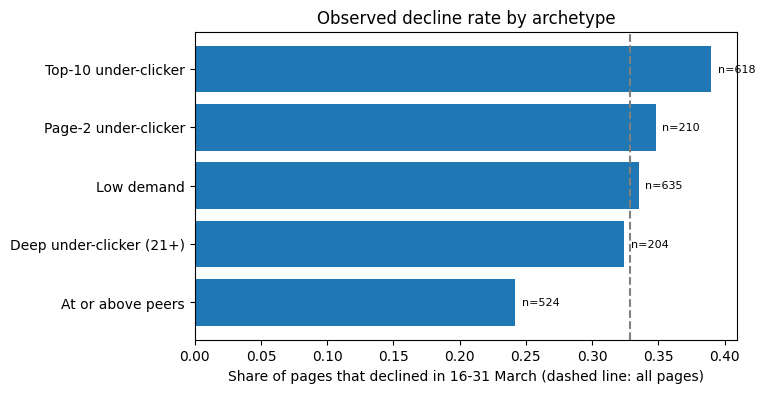

{'run_label': 'w07-playbook-run-01', 'window': 'features 1-15 March 2026, label 16-31 March 2026', 'pages_scored': 2191, 'pages_in_queue': 1032, 'base_rate': 0.329, 'queue_precision_at_50': 0.4, 'note': 'rule-based queue; peer CTR taken from the same sample; observed and directional'}


In [12]:
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# 1) the ranked queue (stays out of git by design; the notebook regenerates it)
cols = ["rank", "content_hash_id", "score", "reason_code", "action", "human_review_required",
        "early_impressions", "early_clicks", "early_ctr", "early_avg_position", "peer_ctr"]
queue[cols].to_csv("work/outputs/playbook_action_queue.csv", index=False)

# 2) a figure for the paper
s = summary.sort_values("declining_rate")
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(s.index, s["declining_rate"])
ax.axvline(y.mean(), linestyle="--", color="gray")
for i, (r, n) in enumerate(zip(s["declining_rate"], s["n"])):
    ax.text(r + 0.005, i, f"n={n}", va="center", fontsize=8)
ax.set_xlabel("Share of pages that declined in 16-31 March (dashed line: all pages)")
ax.set_title("Observed decline rate by archetype")
fig.savefig("work/figures/archetype_decline_rate.png", dpi=150, bbox_inches="tight")
plt.show()

# 3) the receipts
metrics = {
    "run_label": "w07-playbook-run-01",
    "window": "features 1-15 March 2026, label 16-31 March 2026",
    "pages_scored": int(len(d)), "pages_in_queue": int(len(queue)),
    "base_rate": round(float(y.mean()), 3),
    "queue_precision_at_50": round(float(queue.head(50)["label_declining"].mean()), 3),
    "note": "rule-based queue; peer CTR taken from the same sample; observed and directional",
}
json.dump(metrics, open("work/outputs/playbook_metrics.json", "w"), indent=2)
print(metrics)

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.